# Filtres RIF

In [1]:
import numpy as np
from scipy import special
import matplotlib.pyplot as plt
plt.style.use('../../src/signal.mplstyle')

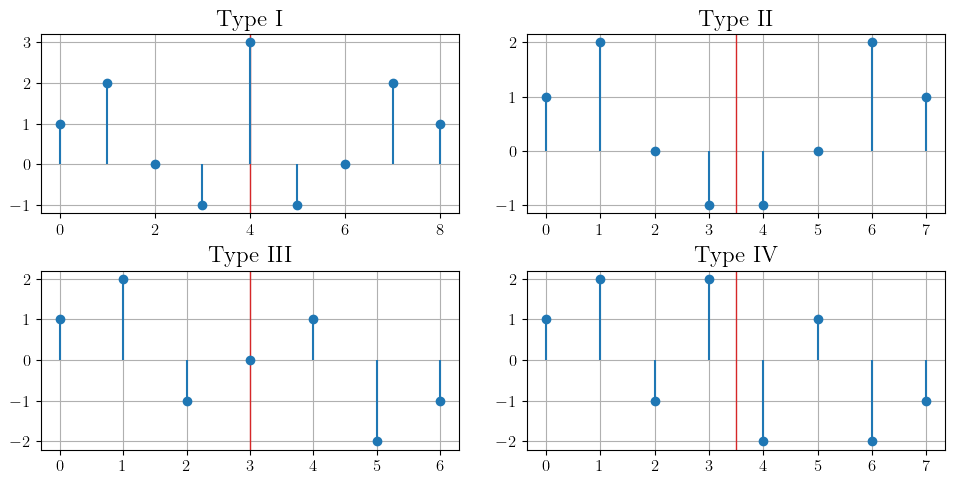

In [2]:
hs = [
    [1, 2, 0, -1, 3, -1, 0, 2, 1],
    [1, 2, 0, -1, -1, 0, 2, 1],
    [1, 2, -1, 0, 1, -2, -1],
    [1, 2, -1, 2, -2, 1, -2, -1]
]
vline = [4, 3.5, 3, 3.5]
types = ["I", "II", "III", "IV"]

fig, axs = plt.subplots(2, 2, figsize=(10,5))
fig.tight_layout(pad=1.4)
axs = np.ravel(axs)

for i in range(len(hs)):
    
    h = hs[i]
    N = len(h)
    n = np.arange(N)
    axs[i].axvline(vline[i], color="tab:red", linewidth=1, linestyle="-")
    axs[i].stem(n, h, basefmt=" ")
    axs[i].set_title(f"Type {types[i]}")
    
plt.savefig("rif-types.svg")
plt.savefig("rif-types.png")

In [3]:
# fc = 0.25

# # Réponse impulsionnelle idéale
# nmax = 15
# n = np.arange(-nmax, nmax+1)
# h = 2 * fc * np.sinc(2 * fc * n)
# N = len(n)

# # Réponse impulsionnelle tronquée et causale
# mmax = 5
# m = np.arange(-mmax, mmax+1)
# k = 2 * fc * np.sinc(2 * fc * m)
# M = len(k)

# # Limites
# xlim = [-nmax-.5, nmax+.5]

# # Affichage
# fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8,6))
# fig.tight_layout(pad=1.4)

# ax1.stem(n, h, basefmt=" ", label="Réponse impulsionnelle\ndu filtre idéal")
# ax1.set_xlim(xlim)
# ax1.set_xlabel("$n$")
# ax1.set_ylabel("$h[n]$")
# ax1.legend(loc="upper left")

# ax2.stem(m+mmax, k, basefmt=" ", linefmt="C1-", markerfmt="C1o", label="Réponse impulsionnelle\ntronquée et décalée")
# ax2.set_xlim(xlim)
# ax2.set_xlabel("$n$")
# ax2.set_ylabel("$h[n]$")
# ax2.legend(loc="upper left")

# plt.savefig("fenetre-troncature.svg")

In [4]:
# # Filtre idéal
# fid = np.array([-.5, -fc, -fc, fc, fc, .5])
# Gid = np.array([0, 0, 1, 1, 0, 0])

# # TFTD de la réponse impulsionnelle
# f = np.arange(-.5, .5, 0.001)
# N = 20
# H = np.zeros(f.shape, dtype="complex128")
# for n in np.arange(-N,N+1):
#     H += 2 * fc * np.sinc(2*fc*n) * np.exp(-1j*2*np.pi*f*n)
    
# fig = plt.figure(figsize=(8,3))
# plt.plot(fid, Gid, "tab:blue")
# plt.plot(f, np.abs(H), "tab:orange")
# plt.xlabel("$k$")
# plt.ylabel("$H[k]$")

# plt.savefig("rif-rf.svg")

In [5]:
# # Noyau de Dirichlet

# Ns = [8, 16]
# f = np.arange(-1.5, 1.5, 0.01)

# fig = plt.figure(figsize=(10,5))
# for i in range(len(Ns)):
    
#     N = Ns[i]
#     D = (N+1) * special.diric(2*np.pi*f, N+1)
#     plt.plot(f, D, label=f"N = {N}")
# plt.legend(loc="upper left")
# plt.ylim([-5, 20])
    
# plt.savefig("dirichlet.svg")

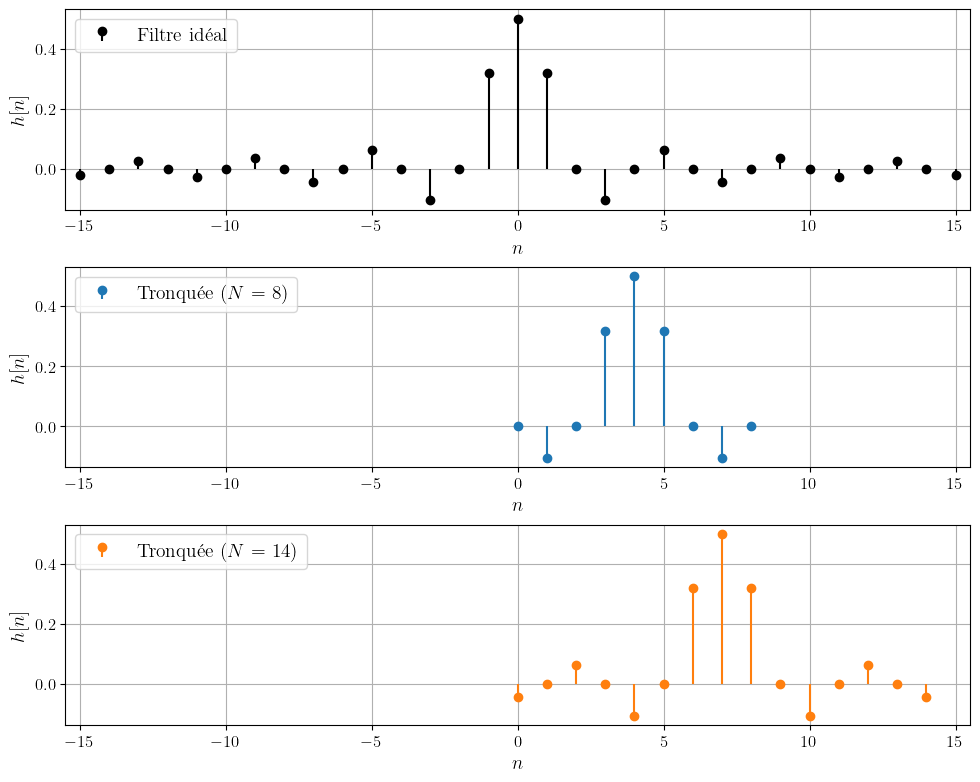

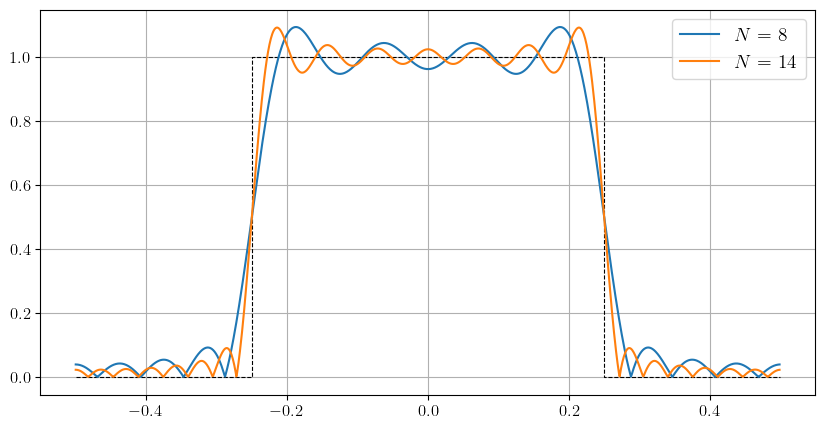

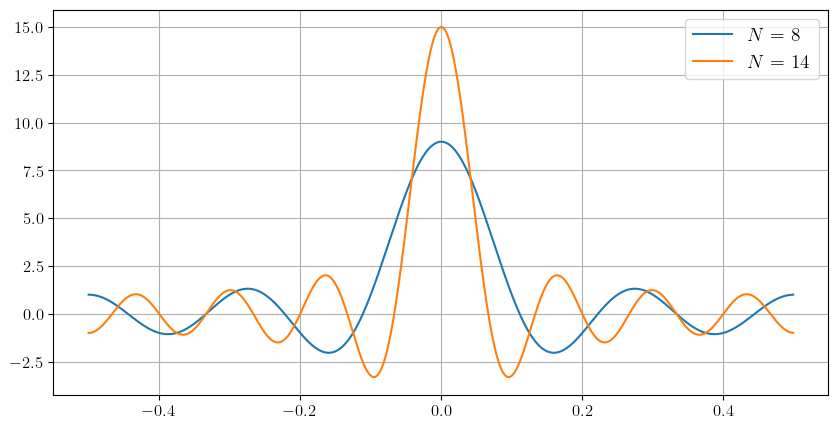

In [6]:
fc = 0.25

# Affichage
fig, axs = plt.subplots(3, 1, figsize=(10,8))
fig.tight_layout(pad=1.4)
fig1, ax1 = plt.subplots(1,1,figsize=(10,5))
fig2, ax2 = plt.subplots(1,1,figsize=(10,5))

# Réponse impulsionnelle idéale
nmax = 15
M = nmax
n = np.arange(-nmax, nmax+1)
h = 2 * fc * np.sinc(2 * fc * n)
N = len(n)

# Limites
xlim = [-nmax-.5, nmax+.5]

# Filtre idéal
fid = np.array([-.5, -fc, -fc, fc, fc, .5])
Gid = np.array([0, 0, 1, 1, 0, 0])

i = 0
axs[i].stem(n, h, basefmt=" ", linefmt="k-", markerfmt="ko", label="Filtre idéal")
axs[i].set_xlim(xlim)
axs[i].set_xlabel("$n$")
axs[i].set_ylabel("$h[n]$")
axs[i].legend(loc="upper left")

ax1.plot(fid, Gid, linewidth=.8, color="k", linestyle="--")


for N in [8, 14]:
    
    i += 1
    
    # Réponse impulsionnelle tronquée et causale
    nmax = N/2
    n = np.arange(-nmax, nmax+1)
    k = 2 * fc * np.sinc(2 * fc * n)
    
    # Limites
    xlim = [-M-.5, M+.5]

    axs[i].stem(n+nmax, k, basefmt=" ", linefmt=f"C{i-1}-", markerfmt=f"C{i-1}o", label=f"Tronquée ($N$ = {N})")
    axs[i].set_xlim(xlim)
    axs[i].set_xlabel("$n$")
    axs[i].set_ylabel("$h[n]$")
    axs[i].legend(loc="upper left")
    
    # TFTD de la réponse impulsionnelle
    fH = np.arange(-.5, .5, 0.001)
    H = np.zeros(fH.shape, dtype="complex128")
    for n in np.arange(-N,N+1):
        H += 2 * fc * np.sinc(2*fc*n) * np.exp(-1j*2*np.pi*fH*n)
    
    # Noyau de Dirichlet
    fD = np.arange(-.5, .5, 0.001)
    D = (N+1) * special.diric(2*np.pi*fD, N+1)

    # Affichage
    ax1.plot(fH, np.abs(H), label=f"$N$ = {N}")
    ax2.plot(fD, D, label=f"$N$ = {N}")

ax1.legend()
ax2.legend()

plt.figure(fig)
plt.savefig("fenetre-troncature.svg")
plt.savefig("fenetre-troncature.png")
plt.figure(fig1)
plt.savefig("rif-rf.svg")
plt.savefig("rif-rf.png")
plt.figure(fig2)
plt.savefig("dirichlet.svg")
plt.savefig("dirichlet.png")